---
title: "Bicycles"
description: "How many bicycles will be rented?"
author: "Mads Chr. Hansen"
date: "2025-03-22"
categories: [Numpyro]
image: "https://images.unsplash.com/photo-1533788179956-82e8a027c962?q=80&w=2070&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
format:
  html:
    code-fold: true
    code-tools: true
toc: true
---

In [1]:
import os
import warnings

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import numpyro.optim as optim
import pandas as pd
import seaborn as sns
from jax import random, vmap
from jaxtyping import Array, Float, Int
from numpyro.contrib.hsgp.approximation import hsgp_matern
from numpyro.diagnostics import hpdi, print_summary
from numpyro.infer import SVI, Predictive, Trace_ELBO, init_to_value
from numpyro.infer.autoguide import AutoNormal
from sklearn.preprocessing import MinMaxScaler

rng_key = random.PRNGKey(seed=42)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
numpyro.set_platform("cpu")

Import data

In [2]:
data_path = "https://raw.githubusercontent.com/christophM/interpretable-ml-book/master/data/bike.csv"

raw_data_df = pd.read_csv(
    data_path,
    dtype={
        "season": "category",
        "mnth": "category",
        "holiday": "category",
        "weekday": "category",
        "workday": "category",
        "weather": "category",
        "cnt": "int",
    },
)

raw_data_df

,instant,dteday,season,yr,mnth,holiday,weekday,temp,atemp,hum,windspeed,casual,registered,cnt,workday,weather,days_since_2011,cnt_2d_bfr
0,3,2011-01-03,WINTER,2011,JAN,N,MON,1.229108,22.439770,43.7273,16.636703,120,1229,1349,Y,GOOD,2,985
1,4,2011-01-04,WINTER,2011,JAN,N,TUE,1.400000,23.212148,59.0435,10.739832,108,1454,1562,Y,GOOD,3,801
2,5,2011-01-05,WINTER,2011,JAN,N,WED,2.666979,23.795180,43.6957,12.522300,82,1518,1600,Y,GOOD,4,1349
3,6,2011-01-06,WINTER,2011,JAN,N,THU,1.604356,23.929106,51.8261,6.000868,88,1518,1606,Y,GOOD,5,1562
4,7,2011-01-07,WINTER,2011,JAN,N,FRI,1.236534,23.100526,49.8696,11.304642,148,1362,1510,Y,MISTY,6,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,727,2012-12-27,WINTER,2012,DEC,N,THU,3.945849,23.705828,65.2917,23.458911,247,1867,2114,Y,MISTY,726,1013
724,728,2012-12-28,WINTER,2012,DEC,N,FRI,3.906651,24.671564,59.0000,10.416557,644,2451,3095,Y,MISTY,727,441
725,729,2012-12-29,WINTER,2012,DEC,N,SAT,3.906651,24.241600,75.2917,8.333661,159,1182,1341,N,MISTY,728,2114
726,730,2012-12-30,WINTER,2012,DEC,N,SUN,4.024151,23.877800,48.3333,23.500518,364,1432,1796,N,GOOD,729,3095


In [3]:
data_df = raw_data_df.copy()

data_df["date"] = pd.to_datetime("2011-01-01") + data_df["days_since_2011"].apply(
    lambda z: pd.Timedelta(z, unit="D")
)

data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   instant          728 non-null    int64         
 1   dteday           728 non-null    object        
 2   season           728 non-null    category      
 3   yr               728 non-null    int64         
 4   mnth             728 non-null    category      
 5   holiday          728 non-null    category      
 6   weekday          728 non-null    category      
 7   temp             728 non-null    float64       
 8   atemp            728 non-null    float64       
 9   hum              728 non-null    float64       
 10  windspeed        728 non-null    float64       
 11  casual           728 non-null    int64         
 12  registered       728 non-null    int64         
 13  cnt              728 non-null    int64         
 14  workday          728 non-null    category 

Let's plot the data

[Text(0.5, 1.0, 'Registered Riders')]

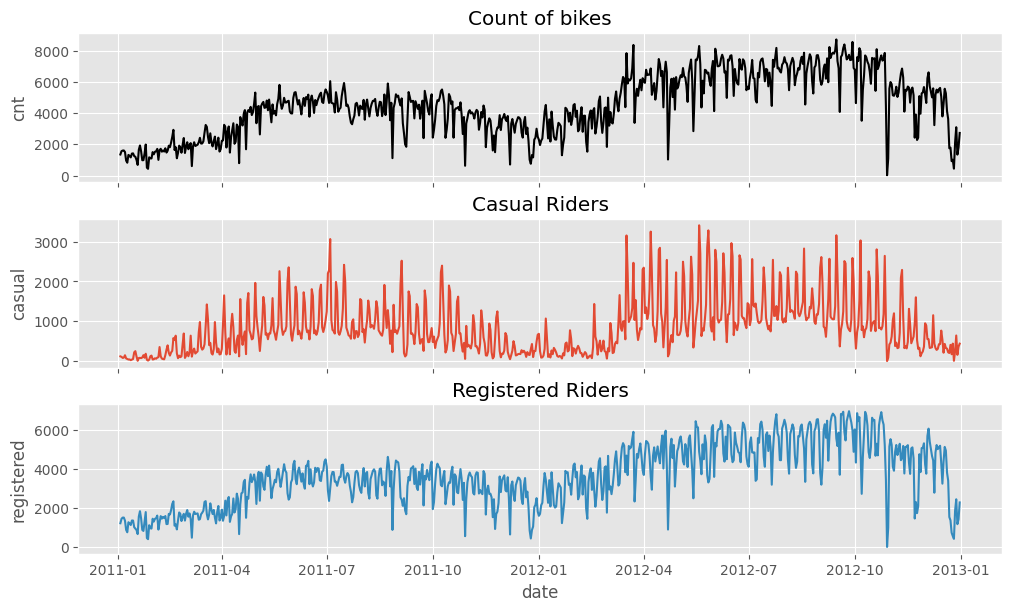

In [12]:
fig, ax = plt.subplots(
    nrows=3, ncols=1, figsize=(10, 6), sharex=True, sharey=False, layout="constrained"
)
sns.lineplot(x="date", y="cnt", data=data_df, color="black", ax=ax[0])
sns.lineplot(x="date", y="casual", data=data_df, color="C0", ax=ax[1])
sns.lineplot(x="date", y="registered", data=data_df, color="C1", ax=ax[2])
ax[0].set(title="Count of bikes")
ax[1].set(title="Casual Riders")
ax[2].set(title="Registered Riders")

[Text(0.5, 1.0, 'Windspeed')]

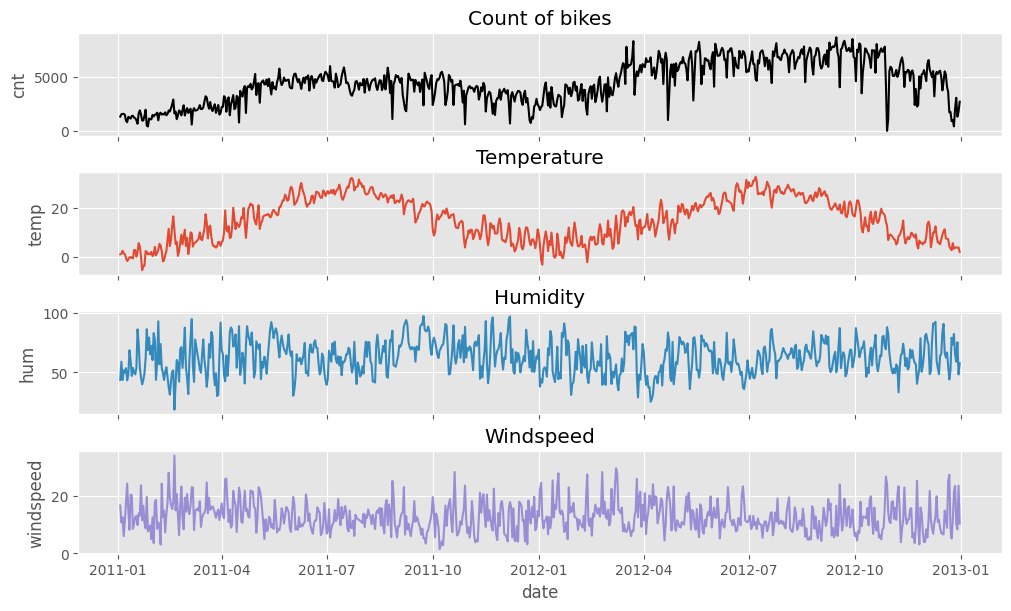

In [13]:
fig, ax = plt.subplots(
    nrows=4, ncols=1, figsize=(10, 6), sharex=True, sharey=False, layout="constrained"
)
sns.lineplot(x="date", y="cnt", data=data_df, color="black", ax=ax[0])
sns.lineplot(x="date", y="temp", data=data_df, color="C0", ax=ax[1])
sns.lineplot(x="date", y="hum", data=data_df, color="C1", ax=ax[2])
sns.lineplot(x="date", y="windspeed", data=data_df, color="C2", ax=ax[3])
ax[0].set(title="Count of bikes")
ax[1].set(title="Temperature")
ax[2].set(title="Humidity")
ax[3].set(title="Windspeed")

We see that the number of bicycles rented is highly impacted by the temperature. Let's see how correlated they are

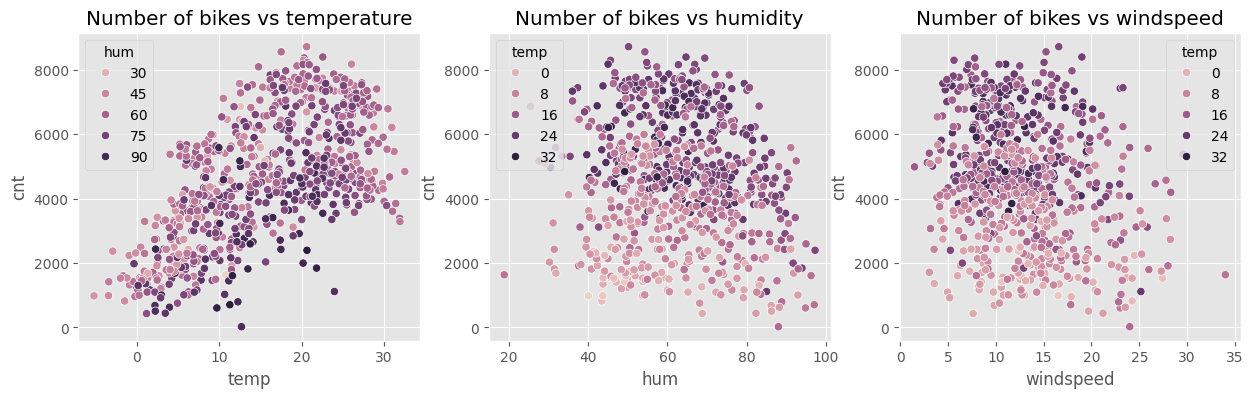

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
sns.scatterplot(x="temp", y="cnt", data=data_df, hue='hum', ax=ax[0])
sns.scatterplot(x="hum", y="cnt", data=data_df, hue='temp', ax=ax[1])
sns.scatterplot(x="windspeed", y="cnt", data=data_df, hue='temp', ax=ax[2])
ax[0].set_title('Number of bikes vs temperature')
ax[1].set_title('Number of bikes vs humidity')
ax[2].set_title('Number of bikes vs windspeed');

<Axes: xlabel='weekday', ylabel='cnt'>

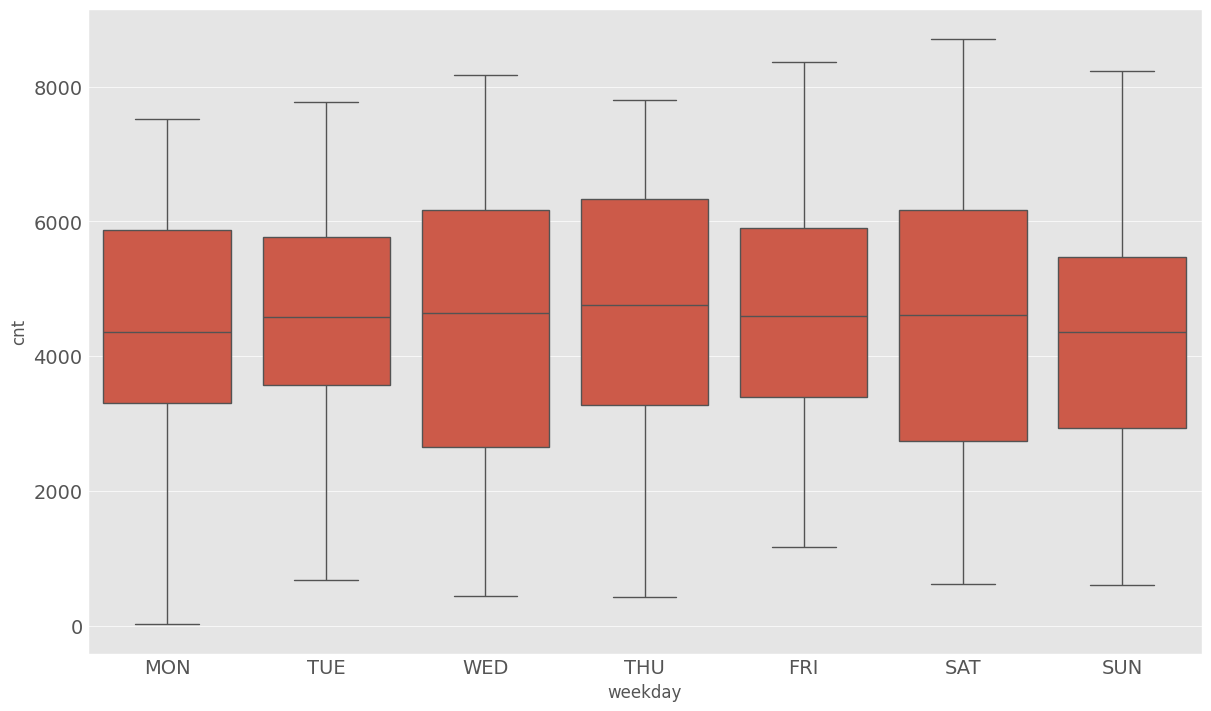

In [90]:
sns.boxplot(x="weekday", y="cnt", data=data_df, order=["MON", "TUE", "WED", "THU", "FRI", "SAT", "SUN"])

<Axes: xlabel='holiday', ylabel='cnt'>

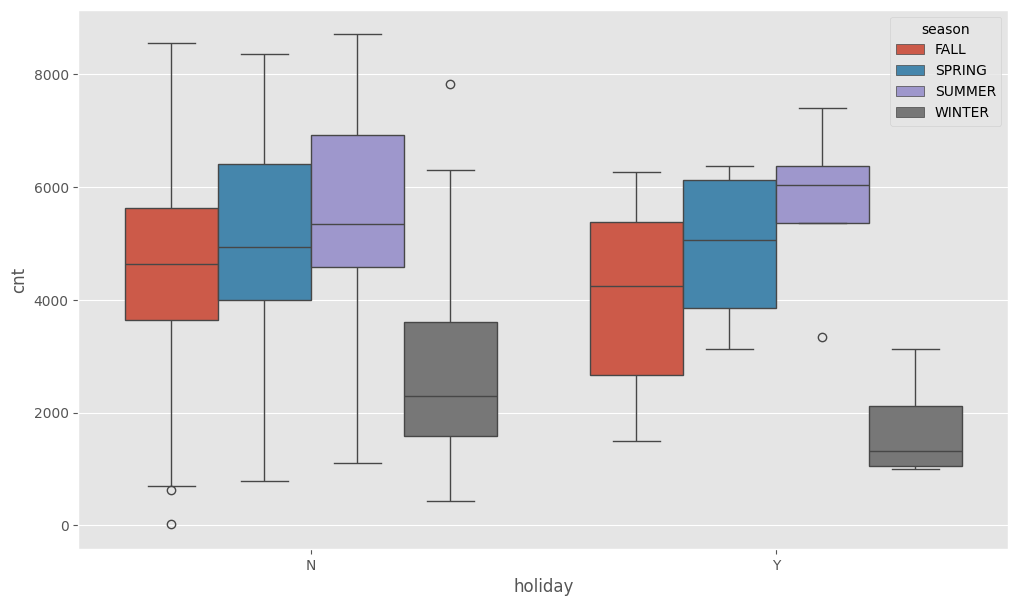

In [10]:
sns.boxplot(x="holiday", y="cnt", data=data_df, hue="season")

<Axes: xlabel='weather', ylabel='cnt'>

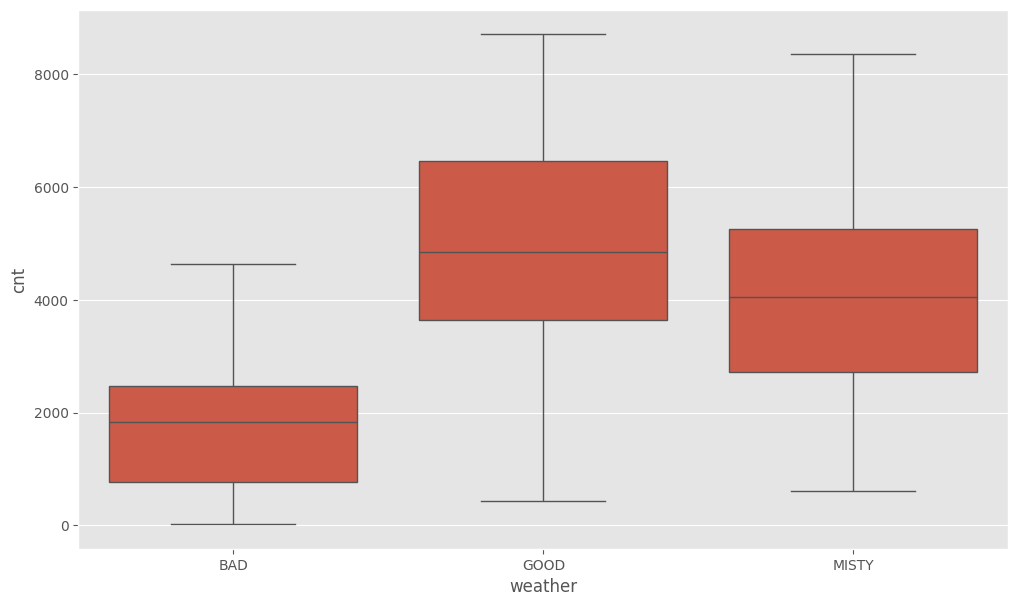

In [8]:
sns.boxplot(x="weather", y="cnt", data=data_df)

# Simple model

In [16]:
target = "cnt"
target_scaled = f"{target}_scaled"

endog_scaler = MinMaxScaler()
exog_scaler = MinMaxScaler()


data_df[target_scaled] = endog_scaler.fit_transform(X=data_df[[target]])
data_df[["temp_scaled", "hum_scaled", "windspeed_scaled"]] = exog_scaler.fit_transform(
    X=data_df[["temp", "hum", "windspeed"]]
)

In [17]:
n = data_df.shape[0]
# target
cnt = jnp.array(data_df[target])
cnt_scaled = jnp.array(data_df[target_scaled])
# date feature
date = data_df["date"].to_numpy()
# model regressors
temp_scaled = jnp.array(data_df["temp_scaled"])
hum_scaled = jnp.array(data_df["hum_scaled"])
windspeed_scaled = jnp.array(data_df["windspeed_scaled"])
holiday_idx, holiday = data_df["holiday"].factorize(sort=True)
workday_idx, workday = data_df["workday"].factorize(sort=True)
weather_idx, weather = data_df["weather"].factorize(sort=True)
t = jnp.array(data_df["days_since_2011"].to_numpy() / data_df["days_since_2011"].max())

In [19]:
def model(
    t,
    temp_scaled,
    hum_scaled,
    windspeed_scaled,
    holiday_idx,
    workday_idx,
    weather_idx,
    cnt_scaled=None,
):
    # Define priors
    intercept = numpyro.sample("intercept", dist.Normal(0, 2))
    b_t = numpyro.sample("b_t", dist.Normal(0, 3))
    b_temp = numpyro.sample("b_temp", dist.Normal(0, 1))
    b_hum = numpyro.sample("b_hum", dist.Normal(0, 1))
    b_windspeed = numpyro.sample("b_windspeed", dist.Normal(0, 0.5))
    b_holiday = numpyro.sample(
        "b_holiday", dist.ZeroSumNormal(1, event_shape=holiday.shape)
    )
    b_workday = numpyro.sample(
        "b_workday", dist.ZeroSumNormal(1, event_shape=workday.shape)
    )
    b_weather = numpyro.sample(
        "b_weathersit", dist.ZeroSumNormal(1, event_shape=weather.shape)
    )

    sigma = numpyro.sample("sigma", dist.HalfNormal(1))
    df = numpyro.sample("df", dist.Gamma(8, 2))
    # Define linear model
    mu = (
        intercept
        + b_t * t
        + b_temp * temp_scaled
        + b_hum * hum_scaled
        + b_windspeed * windspeed_scaled
        + b_holiday[holiday_idx]
        + b_workday[workday_idx]
        + b_weather[weather_idx]
    )
    # Observe data
    with numpyro.plate("data", len(t)):
        numpyro.sample("obs", dist.StudentT(df, mu, sigma), obs=cnt_scaled)

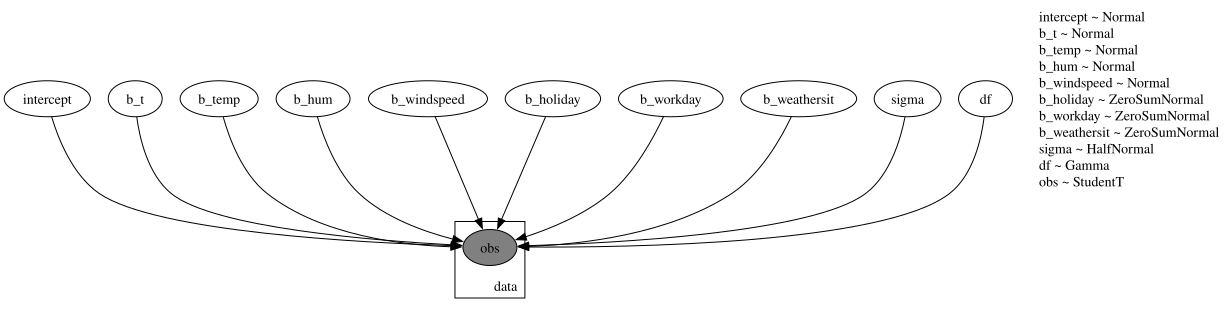

In [20]:
numpyro.render_model(
    model=model,
    model_args=(
        t,
        temp_scaled,
        hum_scaled,
        windspeed_scaled,
        holiday_idx,
        workday_idx,
        weather_idx,
        cnt_scaled,
    ),
    render_distributions=True,
    render_params=True,
)

100%|██████████| 50000/50000 [00:20<00:00, 2445.52it/s, init loss: 1765.1934, avg. loss [47501-50000]: -561.9612]


Text(0.5, 1.0, 'ELBO loss')

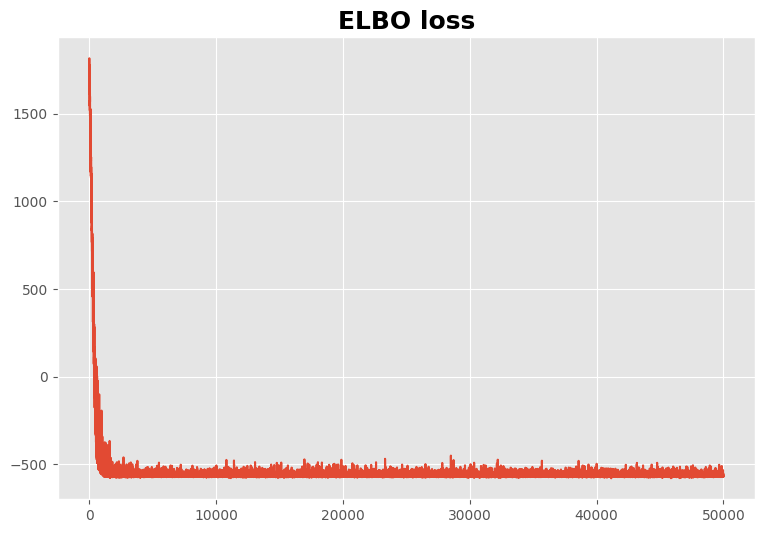

In [21]:
guide = AutoNormal(model)
optimizer = numpyro.optim.Adam(step_size=0.005)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
num_steps = 50_000

rng_key, rng_subkey = random.split(key=rng_key)

svi_result = svi.run(
    rng_subkey,
    num_steps,
    t,
    temp_scaled,
    hum_scaled,
    windspeed_scaled,
    holiday_idx,
    workday_idx,
    weather_idx,
    cnt_scaled,
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(svi_result.losses)
ax.set_title("ELBO loss", fontsize=18, fontweight="bold")

In [22]:
samples = guide.sample_posterior(
    random.PRNGKey(1), svi_result.params, sample_shape=(1000,)
)
print_summary(samples, 0.89, False)


                     mean       std    median      5.5%     94.5%     n_eff     r_hat
   b_holiday[0]      0.03      0.00      0.03      0.02      0.03    967.59      1.00
   b_holiday[1]     -0.03      0.00     -0.03     -0.03     -0.02    967.59      1.00
          b_hum     -0.15      0.01     -0.15     -0.16     -0.14    958.01      1.00
            b_t      0.44      0.01      0.44      0.43      0.45    824.59      1.00
         b_temp      0.50      0.01      0.50      0.49      0.51   1006.46      1.00
b_weathersit[0]     -0.12      0.01     -0.12     -0.13     -0.11    968.93      1.00
b_weathersit[1]      0.08      0.00      0.08      0.07      0.09   1017.30      1.00
b_weathersit[2]      0.04      0.01      0.04      0.03      0.05    974.35      1.00
    b_windspeed     -0.14      0.01     -0.14     -0.15     -0.12   1066.02      1.00
   b_workday[0]     -0.00      0.00     -0.00     -0.01      0.00    996.06      1.00
   b_workday[1]      0.00      0.00      0.00     -0.

In [23]:
posterior_predictive = Predictive(
    model=model,
    guide=guide,
    params=svi_result.params,
    num_samples=5_000,
    # return_sites=["obs"],
)

rng_key, rng_subkey = random.split(rng_key)
posterior_predictive_samples = posterior_predictive(
    rng_subkey,
    t,
    temp_scaled,
    hum_scaled,
    windspeed_scaled,
    holiday_idx,
    workday_idx,
    weather_idx,
)

In [24]:
idata = az.from_dict(
    posterior_predictive={k: v[None, ...] for k, v in posterior_predictive_samples.items()},
    coords={"time": t},
    dims={"obs": ["time"]},
)

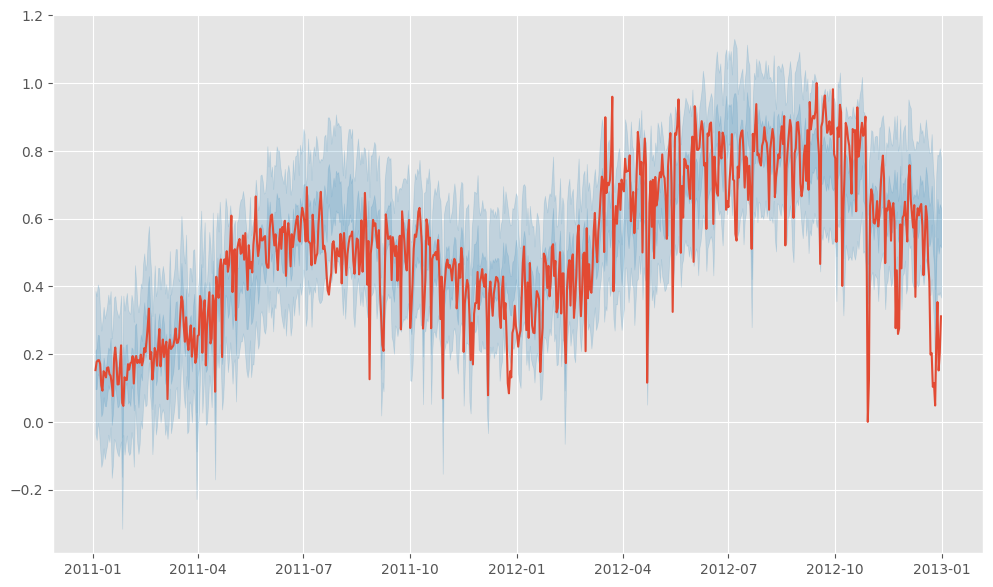

In [29]:
fig, ax = plt.subplots()
az.plot_hdi(
    data_df['date'],
    idata["posterior_predictive"]["obs"],
    hdi_prob=0.94,
    smooth=False,
    fill_kwargs={"alpha": 0.2, "label": "94% HDI"},
    ax=ax,
)
az.plot_hdi(
    data_df['date'],
    idata["posterior_predictive"]["obs"],
    hdi_prob=0.5,
    smooth=False,
    fill_kwargs={"alpha": 0.2, "label": "50% HDI"},
    ax=ax,
)
ax.plot(data_df['date'], cnt_scaled, label="Training Data")

<Axes: xlabel='date', ylabel='cnt_scaled'>

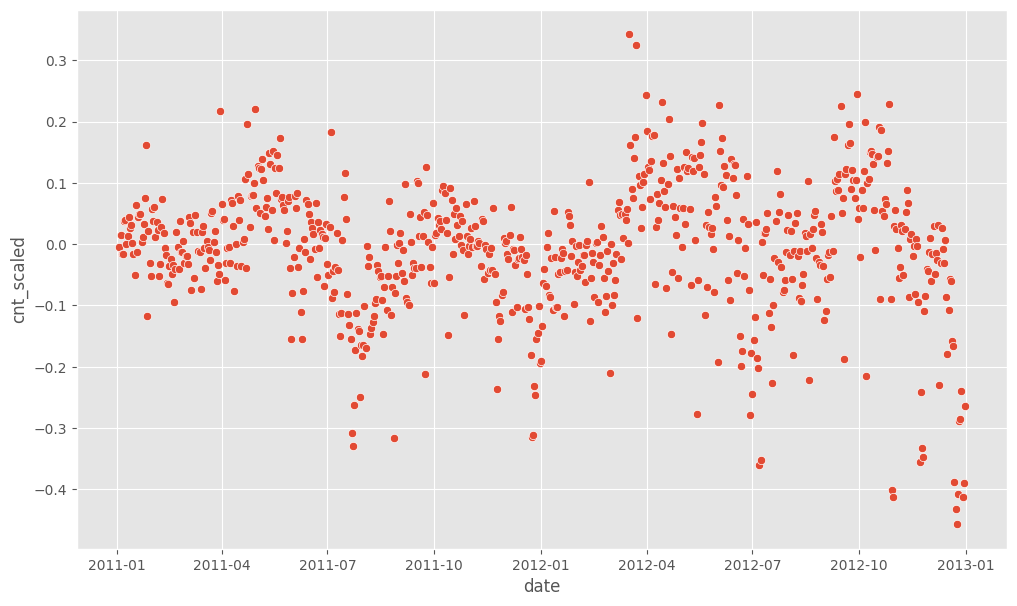

In [38]:
sns.scatterplot(x=data_df['date'], y=data_df['cnt_scaled'] - idata["posterior_predictive"]["obs"].mean(axis=(0,1)))

# Add end of year bump

[Text(0.5, 1.0, 'End-of-Year Gaussian Bump')]

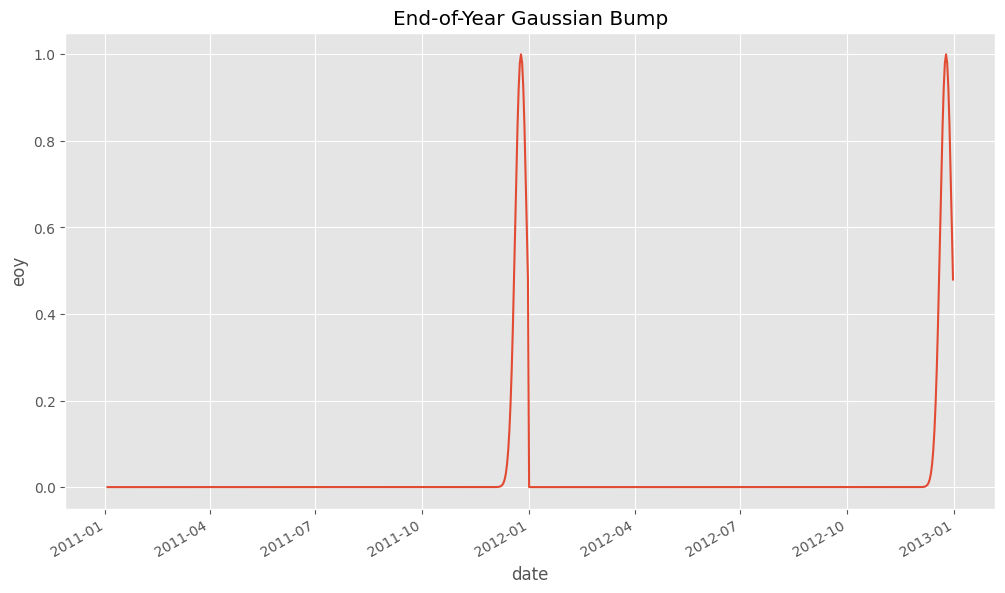

In [39]:
is_december = data_df["date"].dt.month == 12
eoy_mu = 25
eoy_sigma = 7
eoy_arg = (data_df["date"].dt.day - eoy_mu) / eoy_sigma
data_df["eoy"] = is_december * np.exp(-(eoy_arg**2))

fig, ax = plt.subplots()
sns.lineplot(x="date", y="eoy", data=data_df, ax=ax)
fig.get_figure().autofmt_xdate()
ax.set(title="End-of-Year Gaussian Bump")

In [40]:

eoy = jnp.array(data_df["eoy"])

In [41]:
def model(
    t,
    temp_scaled,
    hum_scaled,
    windspeed_scaled,
    holiday_idx,
    workday_idx,
    weather_idx,
    eoy,
    cnt_scaled=None,
):
    # Define priors
    intercept = numpyro.sample("intercept", dist.Normal(0, 2))
    b_t = numpyro.sample("b_t", dist.Normal(0, 3))
    b_temp = numpyro.sample("b_temp", dist.Normal(0, 1))
    b_hum = numpyro.sample("b_hum", dist.Normal(0, 1))
    b_windspeed = numpyro.sample("b_windspeed", dist.Normal(0, 0.5))
    b_holiday = numpyro.sample(
        "b_holiday", dist.ZeroSumNormal(1, event_shape=holiday.shape)
    )
    b_workday = numpyro.sample(
        "b_workday", dist.ZeroSumNormal(1, event_shape=workday.shape)
    )
    b_weather = numpyro.sample(
        "b_weathersit", dist.ZeroSumNormal(1, event_shape=weather.shape)
    )
    b_eoy = numpyro.sample("b_eoy", dist.Normal(0, 1))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1))
    df = numpyro.sample("df", dist.Gamma(8, 2))
    # Define linear model
    mu = (
        intercept
        + b_t * t
        + b_temp * temp_scaled
        + b_hum * hum_scaled
        + b_windspeed * windspeed_scaled
        + b_holiday[holiday_idx]
        + b_workday[workday_idx]
        + b_weather[weather_idx]
        + b_eoy * eoy
    )
    # Observe data
    with numpyro.plate("data", len(t)):
        numpyro.sample("obs", dist.StudentT(df, mu, sigma), obs=cnt_scaled)

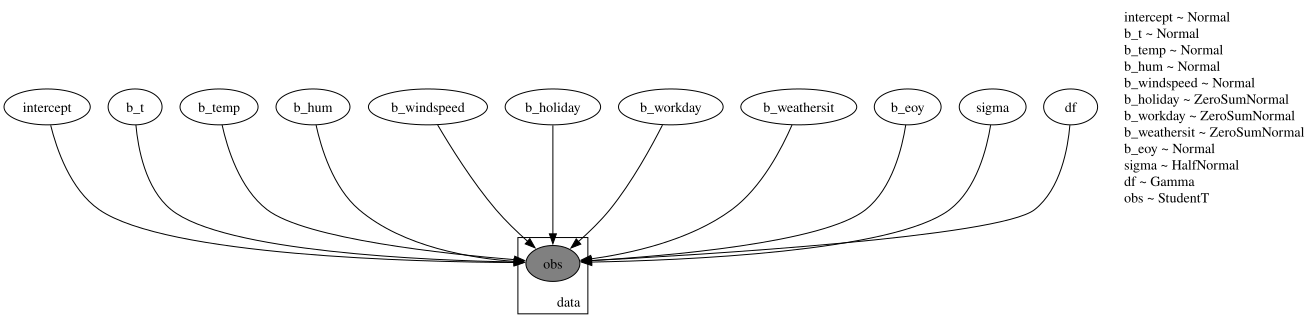

In [42]:
numpyro.render_model(
    model=model,
    model_args=(
        t,
        temp_scaled,
        hum_scaled,
        windspeed_scaled,
        holiday_idx,
        workday_idx,
        weather_idx,
        eoy,
        cnt_scaled,
    ),
    render_distributions=True,
    render_params=True,
)

100%|██████████| 50000/50000 [00:21<00:00, 2304.27it/s, init loss: 1980.0027, avg. loss [47501-50000]: -618.1074]


Text(0.5, 1.0, 'ELBO loss')

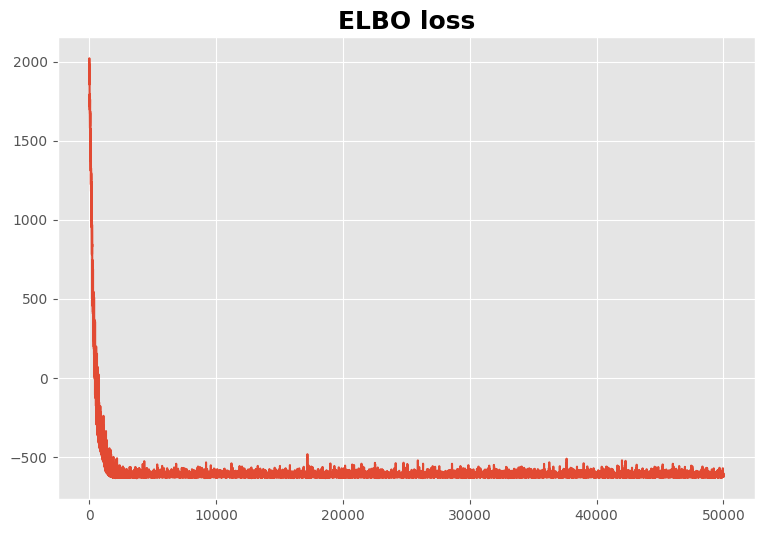

In [43]:
guide = AutoNormal(model)
optimizer = numpyro.optim.Adam(step_size=0.005)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
num_steps = 50_000

rng_key, rng_subkey = random.split(key=rng_key)

svi_result = svi.run(
    rng_subkey,
    num_steps,
    t,
    temp_scaled,
    hum_scaled,
    windspeed_scaled,
    holiday_idx,
    workday_idx,
    weather_idx,
    eoy,
    cnt_scaled,
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(svi_result.losses)
ax.set_title("ELBO loss", fontsize=18, fontweight="bold")

In [44]:
samples = guide.sample_posterior(
    random.PRNGKey(1), svi_result.params, sample_shape=(1000,)
)
print_summary(samples, 0.89, False)


                     mean       std    median      5.5%     94.5%     n_eff     r_hat
          b_eoy     -0.30      0.03     -0.30     -0.35     -0.27    947.94      1.00
   b_holiday[0]      0.02      0.00      0.02      0.02      0.03    967.59      1.00
   b_holiday[1]     -0.02      0.00     -0.02     -0.03     -0.02    967.59      1.00
          b_hum     -0.14      0.01     -0.14     -0.14     -0.13    958.01      1.00
            b_t      0.46      0.01      0.46      0.45      0.47    824.59      1.00
         b_temp      0.47      0.01      0.47      0.46      0.48   1006.46      1.00
b_weathersit[0]     -0.12      0.01     -0.12     -0.13     -0.11    968.91      1.00
b_weathersit[1]      0.08      0.00      0.08      0.07      0.09   1017.18      1.00
b_weathersit[2]      0.04      0.01      0.04      0.04      0.05    974.23      1.00
    b_windspeed     -0.13      0.01     -0.13     -0.15     -0.12   1066.02      1.00
   b_workday[0]     -0.01      0.00     -0.01     -0.

In [45]:
posterior_predictive = Predictive(
    model=model,
    guide=guide,
    params=svi_result.params,
    num_samples=5_000,
    # return_sites=["obs"],
)

rng_key, rng_subkey = random.split(rng_key)
posterior_predictive_samples = posterior_predictive(
    rng_subkey,
    t,
    temp_scaled,
    hum_scaled,
    windspeed_scaled,
    holiday_idx,
    workday_idx,
    weather_idx,
    eoy,
)

In [46]:
idata = az.from_dict(
    posterior_predictive={k: v[None, ...] for k, v in posterior_predictive_samples.items()},
    coords={"time": t},
    dims={"obs": ["time"]},
)

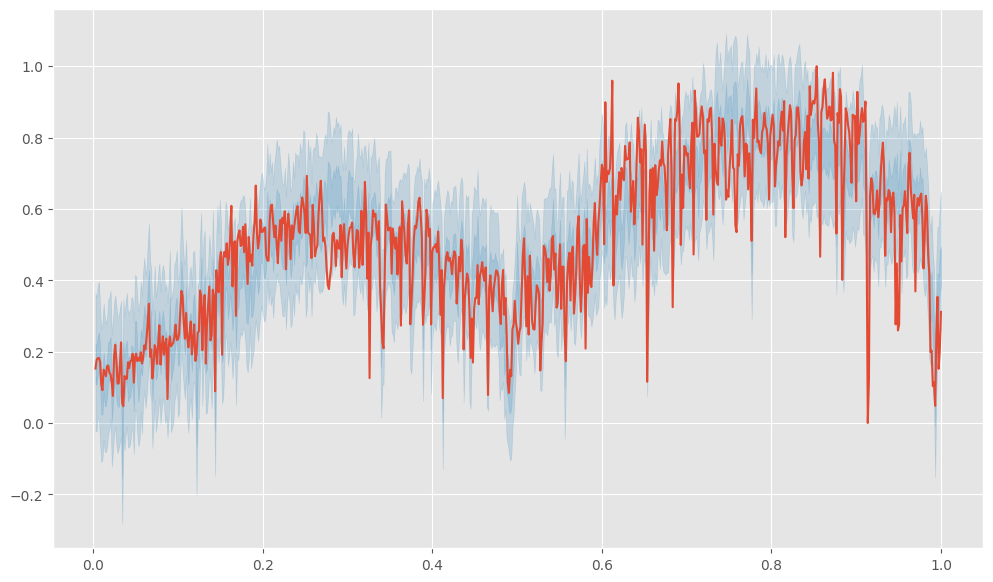

In [47]:
fig, ax = plt.subplots()
az.plot_hdi(
    t,
    idata["posterior_predictive"]["obs"],
    hdi_prob=0.94,
    smooth=False,
    fill_kwargs={"alpha": 0.2, "label": "94% HDI"},
    ax=ax,
)
az.plot_hdi(
    t,
    idata["posterior_predictive"]["obs"],
    hdi_prob=0.5,
    smooth=False,
    fill_kwargs={"alpha": 0.2, "label": "50% HDI"},
    ax=ax,
)
ax.plot(t, cnt_scaled, label="Training Data")

<Axes: xlabel='date', ylabel='cnt_scaled'>

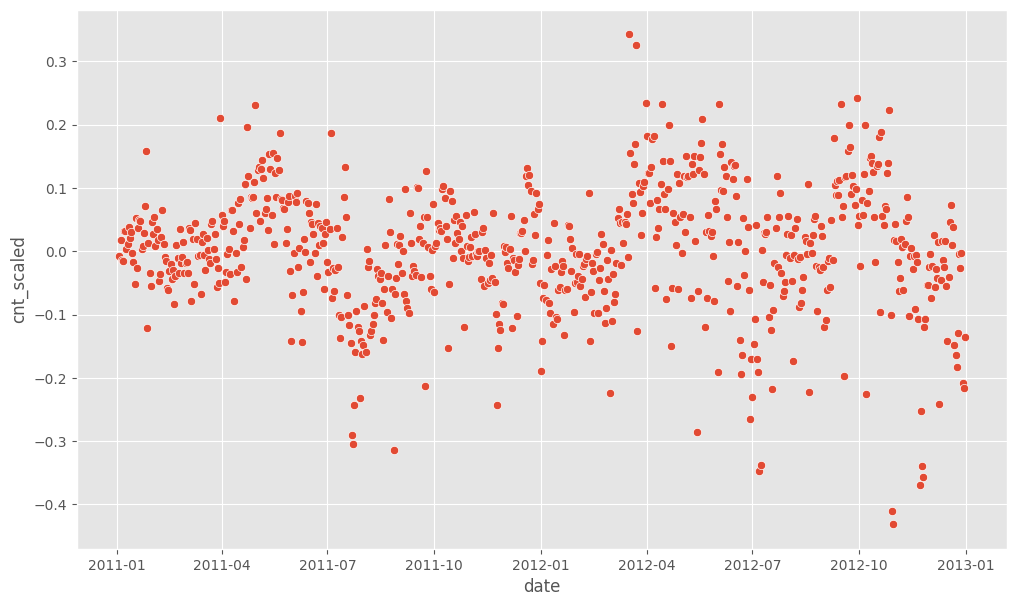

In [48]:
sns.scatterplot(x=data_df['date'], y=data_df['cnt_scaled'] - idata["posterior_predictive"]["obs"].mean(axis=(0,1)))

In [49]:
def model(
    t,
    temp_scaled,
    hum_scaled,
    windspeed_scaled,
    holiday_idx,
    workday_idx,
    weather_idx,
    eoy,
    cnt_scaled=None,
):
    # Define priors
    intercept = numpyro.sample("intercept", dist.Normal(0, 2))
    b_t = numpyro.sample("b_t", dist.Normal(0, 3))
    b_hum = numpyro.sample("b_hum", dist.Normal(0, 1))
    b_windspeed = numpyro.sample("b_windspeed", dist.Normal(0, 0.5))
    b_holiday = numpyro.sample(
        "b_holiday", dist.ZeroSumNormal(1, event_shape=holiday.shape)
    )
    b_workday = numpyro.sample(
        "b_workday", dist.ZeroSumNormal(1, event_shape=workday.shape)
    )
    b_weather = numpyro.sample(
        "b_weathersit", dist.ZeroSumNormal(1, event_shape=weather.shape)
    )
    b_eoy = numpyro.sample("b_eoy", dist.Normal(0, 1))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1))
    df = numpyro.sample("df", dist.Gamma(8, 2))
    sigma_pi = numpyro.sample("sigma_pi", dist.Exponential(1 / 0.2))

    pi = numpyro.sample("pi", dist.GaussianRandomWalk(scale=sigma_pi, num_steps=len(t)))

    # Define linear model
    mu = (
        intercept
        + b_t * t
        + pi * temp_scaled
        + b_hum * hum_scaled
        + b_windspeed * windspeed_scaled
        + b_holiday[holiday_idx]
        + b_workday[workday_idx]
        + b_weather[weather_idx]
        + b_eoy * eoy
    )
    # Observe data
    with numpyro.plate("data", len(t)):
        numpyro.sample("obs", dist.StudentT(df, mu, sigma), obs=cnt_scaled)

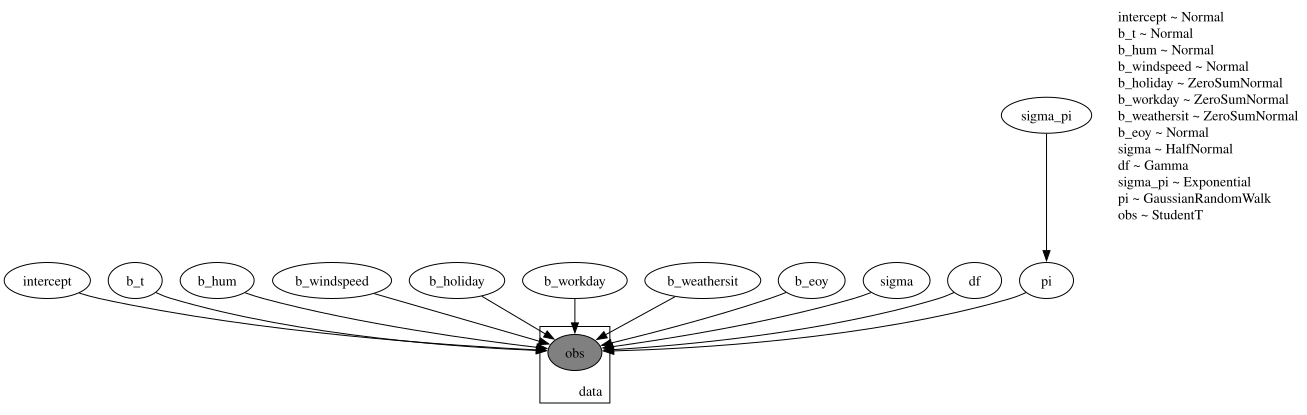

In [50]:
numpyro.render_model(
    model=model,
    model_args=(
        t,
        temp_scaled,
        hum_scaled,
        windspeed_scaled,
        holiday_idx,
        workday_idx,
        weather_idx,
        eoy,
        cnt_scaled,
    ),
    render_distributions=True,
    render_params=True,
)

100%|██████████| 120000/120000 [00:56<00:00, 2131.11it/s, init loss: 5942.5728, avg. loss [114001-120000]: -680.6520]


Text(0.5, 1.0, 'ELBO loss')

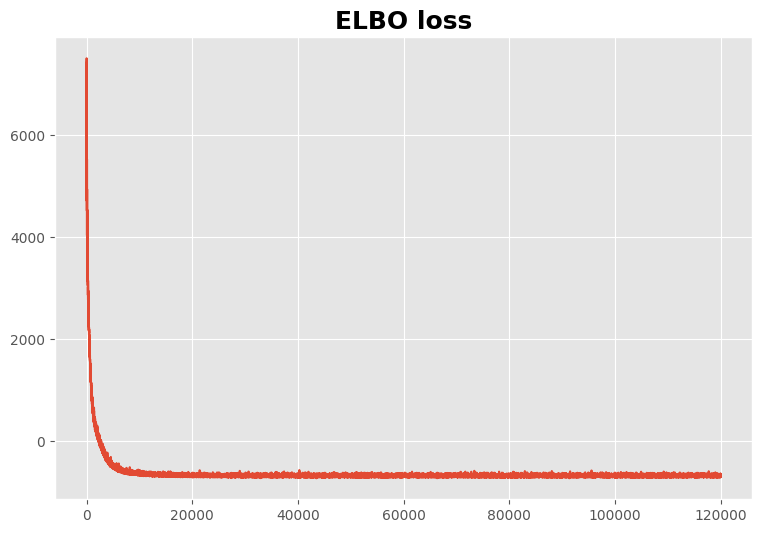

In [51]:
guide = AutoNormal(model)
optimizer = numpyro.optim.Adam(step_size=0.002)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
num_steps = 120_000

rng_key, rng_subkey = random.split(key=rng_key)

svi_result = svi.run(
    rng_subkey,
    num_steps,
    t,
    temp_scaled,
    hum_scaled,
    windspeed_scaled,
    holiday_idx,
    workday_idx,
    weather_idx,
    eoy,
    cnt_scaled,
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(svi_result.losses)
ax.set_title("ELBO loss", fontsize=18, fontweight="bold")

In [52]:
samples = guide.sample_posterior(
    random.PRNGKey(1), svi_result.params, sample_shape=(1000,)
)
print_summary(samples, 0.89, False)


                     mean       std    median      5.5%     94.5%     n_eff     r_hat
          b_eoy     -0.23      0.01     -0.23     -0.25     -0.21    969.17      1.00
   b_holiday[0]      0.02      0.00      0.02      0.02      0.02   1066.02      1.00
   b_holiday[1]     -0.02      0.00     -0.02     -0.02     -0.02   1066.02      1.00
          b_hum     -0.19      0.00     -0.19     -0.19     -0.18   1006.46      1.00
            b_t      0.26      0.00      0.26      0.26      0.27    824.59      1.00
b_weathersit[0]     -0.09      0.00     -0.09     -0.09     -0.08    866.51      1.00
b_weathersit[1]      0.06      0.00      0.06      0.05      0.06   1057.54      1.00
b_weathersit[2]      0.03      0.00      0.03      0.03      0.04    900.74      1.00
    b_windspeed     -0.14      0.00     -0.14     -0.14     -0.13    958.01      1.00
   b_workday[0]     -0.01      0.00     -0.01     -0.01     -0.01    967.59      1.00
   b_workday[1]      0.01      0.00      0.01      0.

<Axes: >

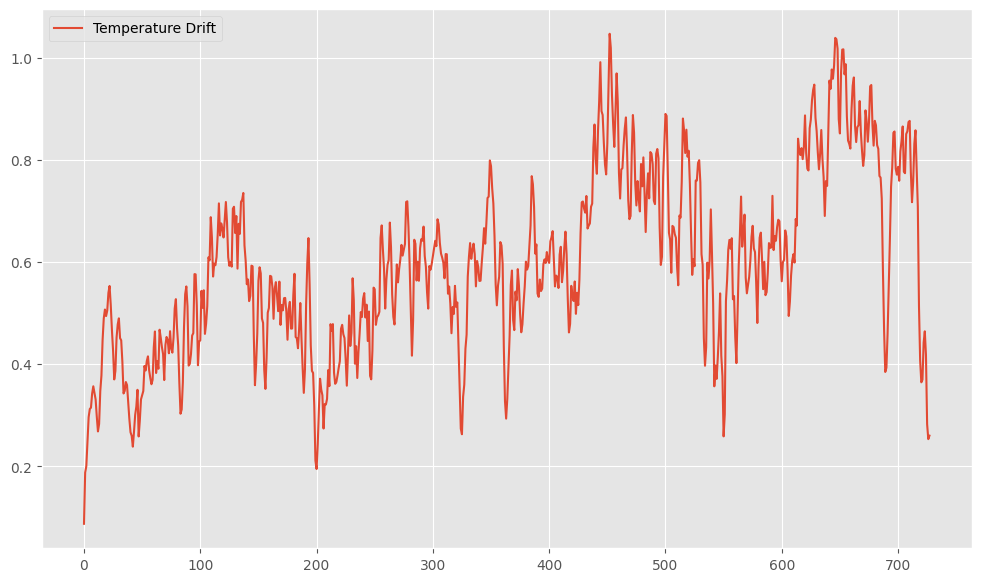

In [62]:
sns.lineplot(samples["pi"].mean(axis=0), label="Temperature Drift")

<Axes: >

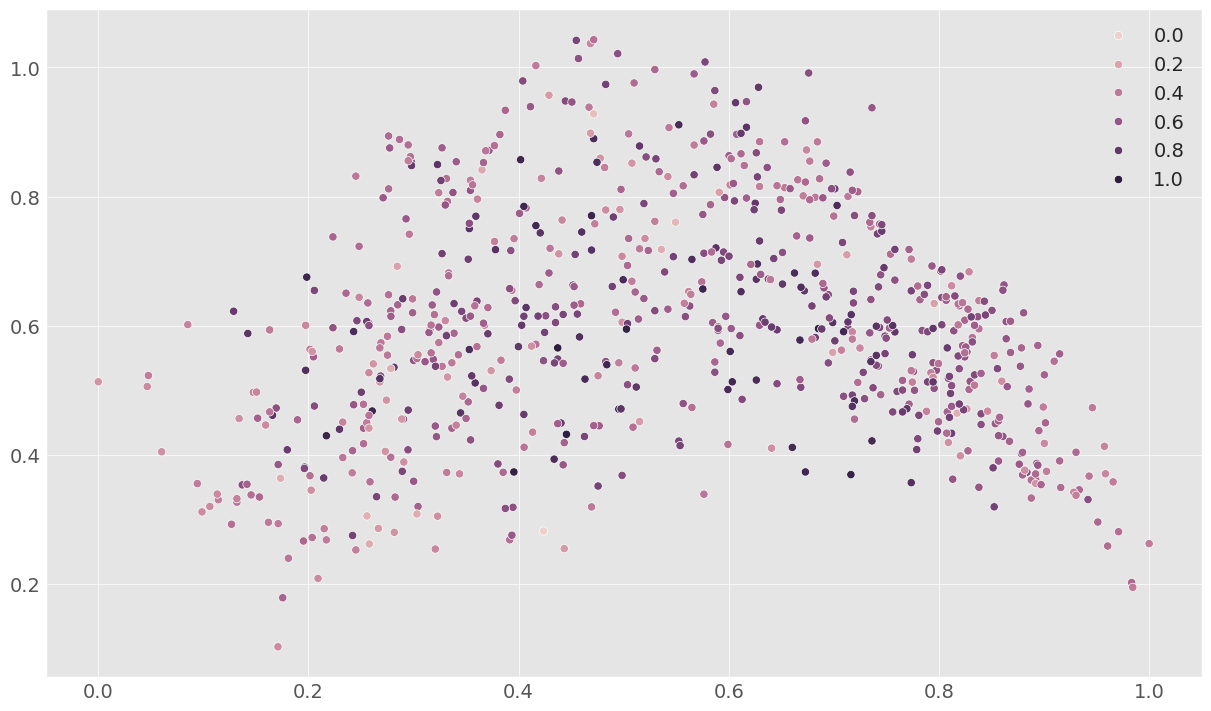

In [74]:
sns.scatterplot(x=temp_scaled, y=samples["pi"].mean(axis=0), hue=hum_scaled)

In [54]:
posterior_predictive = Predictive(
    model=model,
    guide=guide,
    params=svi_result.params,
    num_samples=5_000,
    # return_sites=["obs"],
)

rng_key, rng_subkey = random.split(rng_key)
posterior_predictive_samples = posterior_predictive(
    rng_subkey,
    t,
    temp_scaled,
    hum_scaled,
    windspeed_scaled,
    holiday_idx,
    workday_idx,
    weather_idx,
    eoy,
)

In [59]:
idata = az.from_dict(
    posterior_predictive={k: v[None, ...] for k, v in posterior_predictive_samples.items()},
    coords={"time": t},
    dims={"obs": ["time"]},
)

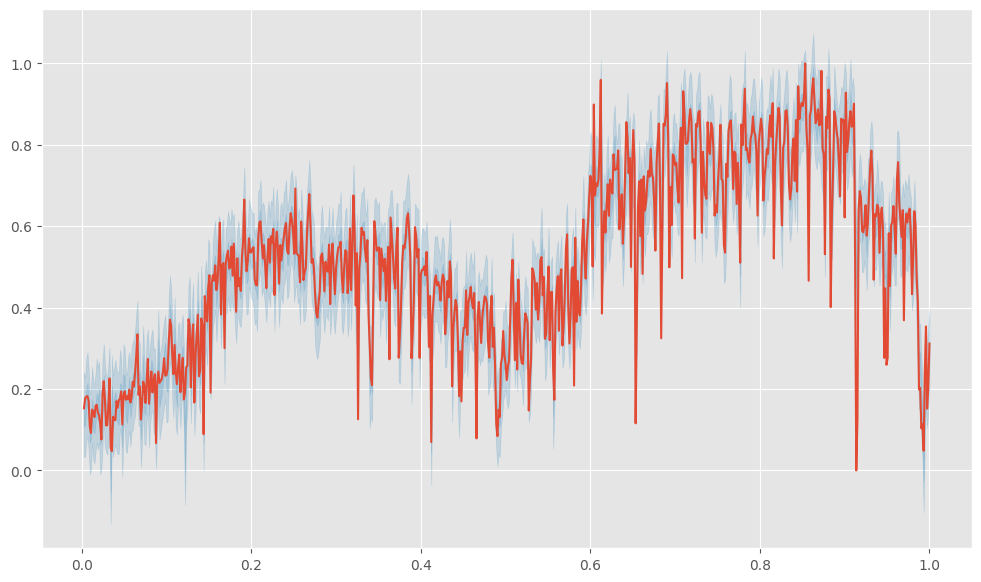

In [60]:
fig, ax = plt.subplots()
az.plot_hdi(
    t,
    idata["posterior_predictive"]["obs"],
    hdi_prob=0.94,
    smooth=False,
    fill_kwargs={"alpha": 0.2, "label": "94% HDI"},
    ax=ax,
)
az.plot_hdi(
    t,
    idata["posterior_predictive"]["obs"],
    hdi_prob=0.5,
    smooth=False,
    fill_kwargs={"alpha": 0.2, "label": "50% HDI"},
    ax=ax,
)
ax.plot(t, cnt_scaled, label="Training Data")

<Axes: xlabel='date', ylabel='cnt_scaled'>

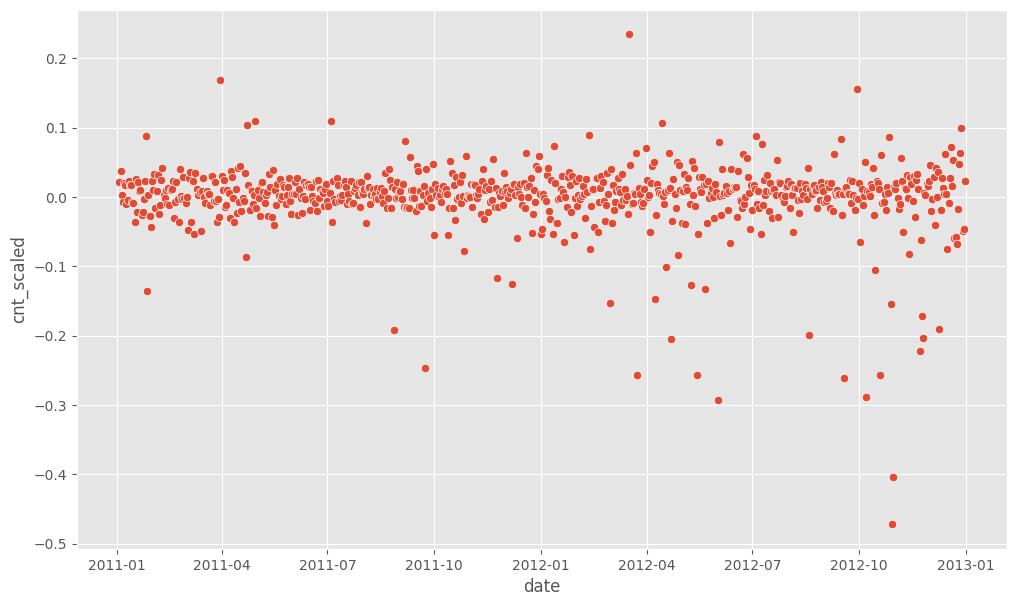

In [61]:
sns.scatterplot(x=data_df['date'], y=data_df['cnt_scaled'] - idata["posterior_predictive"]["obs"].mean(axis=(0,1)))